# Notebook 03 — Marketing Mix Model: Adstock, Saturation, and Channel ROI

**Business question this feeds into:** how should a mobile game measure and optimize UA spend when attribution is unreliable? Notebooks 01 and 02 worked at the *user* level (predicted value, retention experiments). Marketing Mix Modeling (MMM) works at the *channel/budget* level: given weekly spend (or exposure) across channels and a business outcome, how much of that outcome is each channel actually driving, and where should the next incremental dollar go? MMM is the classic answer to attribution-model distrust — it doesn't need a single user's click path to be correctly attributed at all; it only needs aggregate spend and aggregate outcomes over time, which makes it immune to SKAdNetwork thresholds, ATT opt-outs, and MMP-vs-network discrepancies entirely. That's precisely why it has become the standard complement to (and sometimes replacement for) attribution in mobile UA teams over the last few years.

## A framing note before the data: why this notebook doesn't use real mobile game UA spend

I looked for a public dataset of real mobile game UA spend by channel (Meta, Google UAC, Apple Search Ads, TikTok, etc.) with a matching outcome (installs or revenue). **It doesn't exist**, and that's not an oversight — channel-level UA spend and response curves are some of the most commercially sensitive numbers a mobile game studio has. They directly reveal a studio's CAC, its channel mix strategy, and (via the saturation curves this notebook builds) exactly how much budget headroom it has left before hitting diminishing returns — information competitors and ad networks would both love to have. No public dataset with this structure and this level of granularity is going to exist for a real game.

**What this notebook does instead**: it demonstrates the full MMM methodology — geometric adstock (carryover), diminishing-returns saturation, an OLS regression that recovers channel-level contribution, and an ROI/spend-efficiency readout — on `data/Sample Media Spend Data.csv`, a structurally equivalent multi-channel weekly dataset (multiple marketing channels' impressions, tracked weekly, against a downstream `Sales` outcome). The *shape* of this problem — weekly time series, multiple channels competing for credit, a single downstream KPI — is identical to the mobile UA case. In production, this exact pipeline (adstock each channel → saturate → regress with trend/seasonality controls → decompose contribution → derive ROI) would be pointed at real weekly spend from Meta Ads, Google UAC, and Apple Search Ads, with `Sales` replaced by installs or D0/D7 revenue. Every methodological decision below is written to generalize to that substitution; only the specific numbers are illustrative.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.optimize import lsq_linear

pd.set_option('display.max_columns', 20)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#e1e0d9'
plt.rcParams['grid.linewidth'] = 0.6
plt.rcParams['axes.edgecolor'] = '#c3c2b7'
plt.rcParams['axes.axisbelow'] = True

# Fixed categorical colors, one per channel, used consistently in every chart -
# validated for CVD-safe separation (see notebook 02 for the same validation
# workflow applied to that notebook's two-color palette).
CHANNEL_COLORS = {
    'Google_Impressions': '#2a78d6',
    'Facebook_Impressions': '#1baf7a',
    'Email_Impressions': '#eda100',
    'Affiliate_Impressions': '#008300',
}
NEUTRAL = '#898781'
RANDOM_STATE = 42


## 1. Find and inspect the dataset


In [2]:
import os
print([f for f in os.listdir('../data') if f.lower().endswith(('.csv', '.xlsx', '.xls'))])


['cookie_cats.csv', 'mobile_game_inapp_purchases.xlsx', 'Sample Media Spend Data.csv', 'synthetic_mmm_weekly_india.csv']


In [3]:
raw = pd.read_csv('../data/Sample Media Spend Data.csv')
print(raw.shape)
raw.head()


(3051, 10)


,Division,Calendar_Week,Paid_Views,Organic_Views,Google_Impressions,Email_Impressions,Facebook_Impressions,Affiliate_Impressions,Overall_Views,Sales
0,A,1/6/2018,392,422,408,349895.0107,73580,12072,682,59417
1,A,1/13/2018,787,904,110,506270.2176,11804,9499,853,56806
2,A,1/20/2018,81,970,742,430042.1538,52232,17048,759,48715
3,A,1/27/2018,25,575,65,417745.6658,78640,10207,942,72047
4,A,2/3/2018,565,284,295,408505.8012,40561,5834,658,56235


In [4]:
raw.dtypes


Division                     str
Calendar_Week                str
Paid_Views                 int64
Organic_Views              int64
Google_Impressions         int64
Email_Impressions        float64
Facebook_Impressions       int64
Affiliate_Impressions      int64
Overall_Views              int64
Sales                      int64
dtype: object

In [5]:
print('Nulls per column:')
print(raw.isnull().sum())


Nulls per column:
Division                 0
Calendar_Week            0
Paid_Views               0
Organic_Views            0
Google_Impressions       0
Email_Impressions        0
Facebook_Impressions     0
Affiliate_Impressions    0
Overall_Views            0
Sales                    0
dtype: int64


Columns: `Division` (a business-unit/market code), `Calendar_Week`, four **channel exposure** columns (`Google_Impressions`, `Email_Impressions`, `Facebook_Impressions`, `Affiliate_Impressions`), two view/traffic columns (`Paid_Views`, `Organic_Views`, `Overall_Views`), and `Sales` — the downstream business outcome. No nulls.

**Important honest caveat up front**: this dataset gives channel **impressions**, not channel **spend in dollars**. That matters for the ROI section later (Section 8) — I'll flag exactly how I handle it when we get there, rather than silently pretending impressions are spend.


## 2. Data structure — choosing a single clean weekly series to model

`Division` isn't a single national time series — it's a panel.


In [6]:
print('Number of divisions:', raw['Division'].nunique())
print(raw['Division'].value_counts())


Number of divisions: 26
Division
Z    226
A    113
B    113
C    113
D    113
E    113
F    113
G    113
H    113
I    113
J    113
K    113
L    113
M    113
N    113
O    113
P    113
Q    113
R    113
S    113
T    113
U    113
V    113
W    113
X    113
Y    113
Name: count, dtype: int64


26 division codes (A–Z), each with 113 weekly rows — **except `Z`, which has 226**: exactly double, with two rows sharing every calendar week.


In [7]:
z = raw[raw['Division'] == 'Z'].copy()
z['date'] = pd.to_datetime(z['Calendar_Week'])
print('Weeks with exactly 2 rows in Division Z:', (z['date'].value_counts() == 2).sum(), 'out of', z['date'].nunique())


Weeks with exactly 2 rows in Division Z: 113 out of 113


Every single week in `Z` has exactly two rows — that's not a real division, it's a labeling artifact (most likely two different data pulls both mistakenly tagged `Z`). Decision: **drop `Z`** and don't try to reconcile which of its two rows per week is "correct" — there's no way to tell from this data, and guessing would be worse than excluding it.

That still leaves 25 legitimate divisions, each a full 113-week panel. A rigorous production MMM would either run a hierarchical/pooled model across all of them (sharing adstock/saturation shape while letting baselines vary by division) or model each separately. Both add real complexity — pooling requires a mixed-effects or Bayesian hierarchical setup to avoid pretending 25 markets share one intercept, and modeling all 25 separately means writing this whole pipeline once and running it 25 times. **Decision: model a single division (`A`) as one clean weekly time series.** This keeps every transformation and modeling choice below fully inspectable end-to-end, which is the point of an interview-defensible notebook — and it's exactly the same simplification notebook 01 made explicit when it used a single cross-sectional snapshot instead of a full cohort panel. Pooling across divisions is flagged as a concrete extension in the limitations section.


In [8]:
division = raw[raw['Division'] == 'A'].copy()
division['date'] = pd.to_datetime(division['Calendar_Week'])
division = division.sort_values('date').reset_index(drop=True)
division['t'] = np.arange(len(division))

print('Rows:', len(division))
print('Date range:', division['date'].min().date(), 'to', division['date'].max().date())
print('Weekly gaps (should all be 7 days):')
print(division['date'].diff().value_counts())


Rows: 113
Date range: 2018-01-06 to 2020-02-29
Weekly gaps (should all be 7 days):
date
7 days    112
Name: count, dtype: int64


113 consecutive weekly observations, no gaps — a clean, evenly-spaced time series, which matters because the adstock transform in Section 4 assumes a fixed time step between rows.


## 3. Channels, outcome, and why raw correlation is the wrong way to read this data

Four media channels, one outcome:


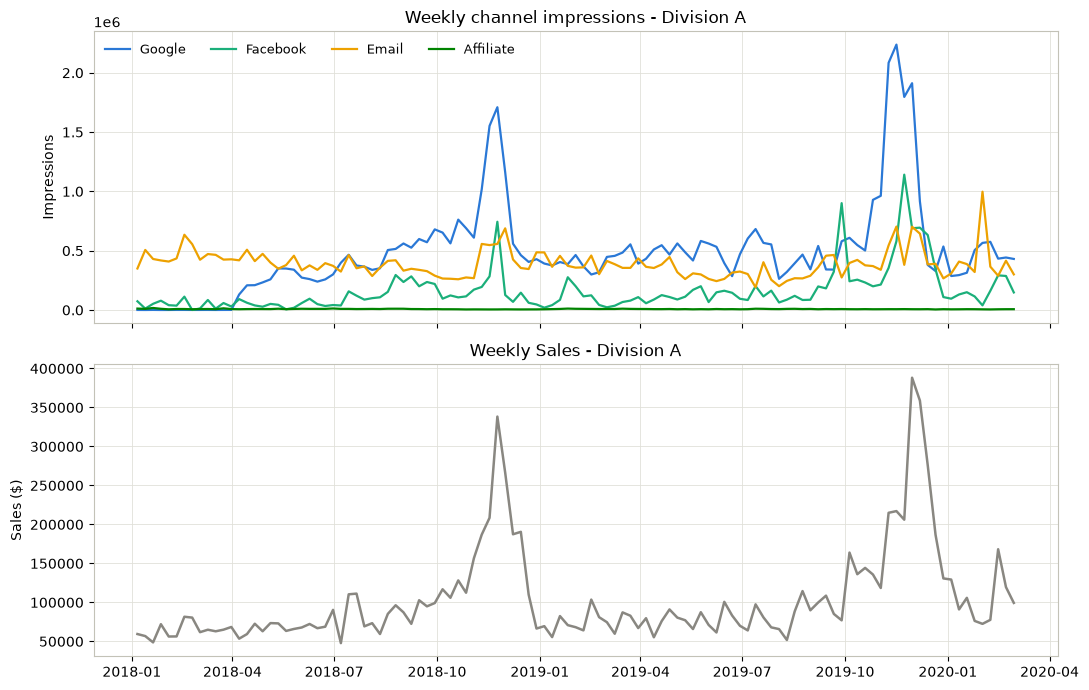

In [9]:
CHANNELS = ['Google_Impressions', 'Facebook_Impressions', 'Email_Impressions', 'Affiliate_Impressions']

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for c in CHANNELS:
    axes[0].plot(division['date'], division[c], color=CHANNEL_COLORS[c], linewidth=1.6, label=c.replace('_Impressions', ''))
axes[0].set_title('Weekly channel impressions - Division A')
axes[0].set_ylabel('Impressions')
axes[0].legend(frameon=False, ncol=4, fontsize=9)

axes[1].plot(division['date'], division['Sales'], color=NEUTRAL, linewidth=1.8)
axes[1].set_title('Weekly Sales - Division A')
axes[1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.show()


In [10]:
print('Raw correlation with Sales:')
for c in CHANNELS:
    print(f'  {c:24s} r = {division[c].corr(division["Sales"]):+.3f}')


Raw correlation with Sales:
  Google_Impressions       r = +0.712
  Facebook_Impressions     r = +0.684
  Email_Impressions        r = +0.381
  Affiliate_Impressions    r = -0.399


`Affiliate_Impressions` shows a **negative** raw correlation with Sales (-0.40). Taken at face value that would say "affiliate marketing is hurting sales," which should immediately raise suspicion rather than get reported. Checking why:


In [11]:
print('Trend in each series (correlation with week index t):')
for c in CHANNELS + ['Sales']:
    print(f'  {c:24s} corr with t = {division[c].corr(division["t"]):+.3f}')


Trend in each series (correlation with week index t):
  Google_Impressions       corr with t = +0.438
  Facebook_Impressions     corr with t = +0.432
  Email_Impressions        corr with t = -0.081
  Affiliate_Impressions    corr with t = -0.388
  Sales                    corr with t = +0.370


Sales trends up over the 113 weeks (r = +0.37 with time), Google and Facebook impressions both trend up alongside it, and **Affiliate impressions trend down** (r = -0.39). Affiliate's negative raw correlation with Sales is at least partly a **shared-trend artifact**: two series that both move monotonically over time will show a spurious correlation with each other regardless of any real causal link, and here Affiliate happens to be trending in the opposite direction from a Sales series that's rising for reasons (likely Google/Facebook growth, or organic growth) that have nothing to do with Affiliate itself.

This is the single most important reason MMM exists as a discipline rather than "just correlate spend with sales": **naive correlation conflates trend, seasonality, and cross-channel co-movement with true causal response.** Section 6 checks whether controlling for trend resolves this, and Section 7 checks whether it survives once every channel is modeled jointly (spoiler: it partially resolves, and the full story only becomes clear in the regression).


## 4. Adstock — modeling carryover

An ad seen this week doesn't only affect this week's decision to buy — some of its influence carries into future weeks (a shopper remembers the ad, or acts on it days later). This is **advertising carryover**, formalized as "adstock" by Broadbent (1979) and used in essentially every MMM since. The standard functional form is **geometric decay**:

$$\text{adstock}_t = x_t + \lambda \cdot \text{adstock}_{t-1}$$

where $x_t$ is this week's raw impressions and $\lambda \in [0, 1)$ is the **decay rate** — the fraction of last week's *carried* effect that's still active this week. $\lambda = 0$ means no carryover (each week stands alone); $\lambda$ close to 1 means an impression's influence barely fades and keeps compounding for many weeks. This is a recursive (infinite-impulse-response) filter, so a single week's exposure technically influences every future week, just by a shrinking amount ($\lambda^k$ after $k$ weeks) — which is exactly the "advertising has a fading echo" intuition it's meant to capture.


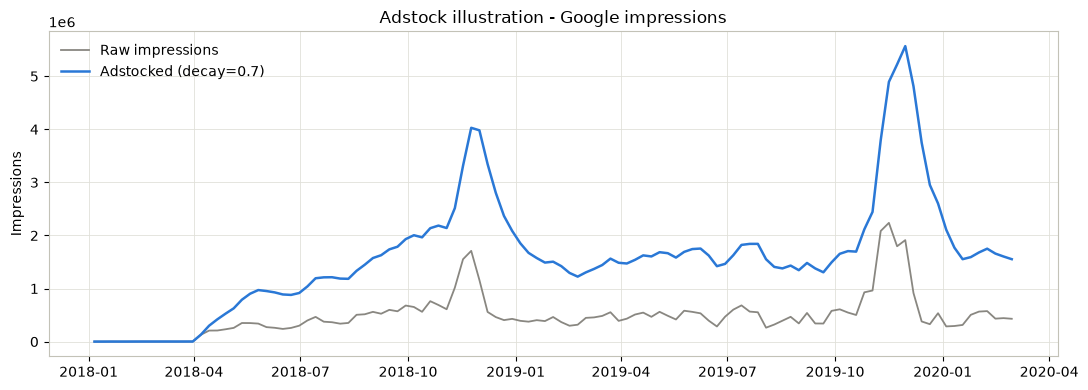

In [12]:
def adstock(x, decay):
    # Geometric adstock: out[t] = x[t] + decay * out[t-1]
    out = np.zeros_like(x, dtype=float)
    out[0] = x[0]
    for i in range(1, len(x)):
        out[i] = x[i] + decay * out[i - 1]
    return out

# Illustration: Google impressions, raw vs. adstocked at a high decay rate,
# to make the carryover/smoothing effect visible before it gets tuned per channel.
example_decay = 0.7
google_raw = division['Google_Impressions'].values.astype(float)
google_adstocked = adstock(google_raw, example_decay)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(division['date'], google_raw, color=NEUTRAL, linewidth=1.3, label='Raw impressions')
ax.plot(division['date'], google_adstocked, color=CHANNEL_COLORS['Google_Impressions'], linewidth=1.8,
        label=f'Adstocked (decay={example_decay})')
ax.set_title('Adstock illustration - Google impressions')
ax.set_ylabel('Impressions')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


The adstocked series is smoother and lags the raw spikes — exactly the "carryover echo" the transform is meant to model. The decay value here (0.7) is illustrative; Section 6 tunes an actual decay per channel from the data rather than assuming one number fits all four.


## 5. Saturation — modeling diminishing returns

Media response isn't linear in exposure. The first impressions a person sees are the most persuasive; by the hundredth, most of the audience that was ever going to respond already has, and additional impressions mostly land on people who've already decided (or decided against it). This is **diminishing marginal returns**, and it's the second half of every MMM's media transform, applied *after* adstock (carryover first, then diminishing returns on the carried-forward exposure).

The simplest functional form that captures "increasing, but at a decreasing rate" is a **power transform**:

$$\text{response} = (\text{adstocked exposure})^{\alpha}, \quad 0 < \alpha \le 1$$

$\alpha = 1$ means no saturation (linear response); as $\alpha$ shrinks toward 0, the curve flattens faster — more of the channel's exposure is "wasted" on an already-saturated audience. (Production MMM tools like Meta's Robyn more often use a two-parameter Hill/S-curve for extra flexibility; the single-parameter power transform is the standard simpler alternative and is enough to demonstrate the concept and get a real, data-driven diminishing-returns fit here.)


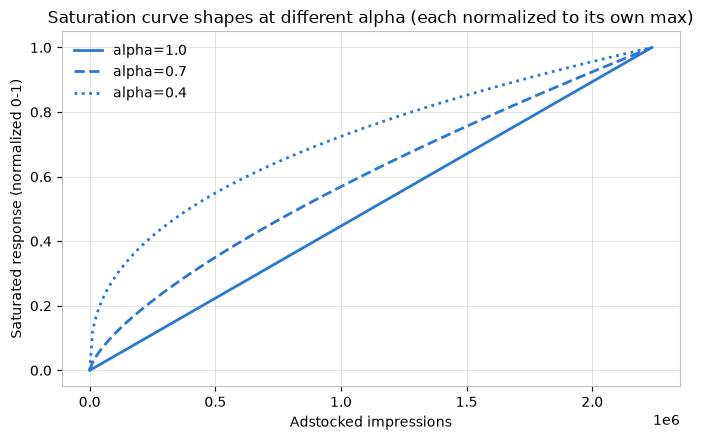

In [13]:
def saturate(x, alpha):
    # Power-law diminishing returns: monotonic, concave for alpha < 1
    return np.power(x, alpha)

# Illustration: what different alpha values do to a 0-to-max impressions range.
# Each curve is normalized by its own max so the *shape* is comparable on one
# axis -- raw x^0.4 and x^0.7 are numerically tiny next to x^1.0 at this scale
# (millions of impressions), which would otherwise flatten them to invisible
# near-zero lines and defeat the point of the illustration.
x_grid = np.linspace(0, google_raw.max(), 200)
fig, ax = plt.subplots(figsize=(7, 4.5))
for alpha, style in [(1.0, '-'), (0.7, '--'), (0.4, ':')]:
    curve = saturate(x_grid, alpha)
    curve = curve / curve.max()
    ax.plot(x_grid, curve, linestyle=style, color=CHANNEL_COLORS['Google_Impressions'],
            linewidth=2, label=f'alpha={alpha}')
ax.set_title('Saturation curve shapes at different alpha (each normalized to its own max)')
ax.set_xlabel('Adstocked impressions')
ax.set_ylabel('Saturated response (normalized 0-1)')
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Lower alpha bends the curve over faster — the channel "runs out of room" at lower exposure levels. Section 6 fits alpha per channel from the data rather than picking one arbitrarily.


## 6. Choosing adstock decay and saturation alpha per channel

Neither $\lambda$ (decay) nor $\alpha$ (saturation shape) is known ahead of time, and they're specific to each channel — Search-intent clicks (Google) plausibly convert fast with little carryover, while a Facebook awareness impression plausibly lingers longer. **Decision: grid-search both parameters per channel**, choosing the combination that maximizes each channel's own **partial correlation with Sales, controlling for the linear time trend** — not the raw correlation, because Section 3 just showed raw correlation is contaminated by shared trend. Partial correlation removes a fitted linear trend from *both* the transformed channel and Sales before correlating what's left, which isolates the within-trend co-movement.

This is a **pragmatic, univariate pre-tuning heuristic**, not the most rigorous approach — production MMM tools (Robyn, Google's LightweightMMM) jointly optimize every channel's decay and saturation *simultaneously* inside the full multivariate model, usually via Bayesian or evolutionary optimization, because a channel's best-looking univariate parameters aren't guaranteed to be its best parameters once every other channel is controlled for. I'm using the simpler per-channel heuristic here for transparency and compute cost, and flagging the joint-optimization gap explicitly as a limitation (Section 12) rather than pretending this is production-grade parameter search.


In [14]:
def partial_corr_vs_trend(x, y, t):
    # Correlation between x and y after removing each one's fitted linear trend on t
    T = np.column_stack([np.ones_like(t), t])
    bx, *_ = np.linalg.lstsq(T, x, rcond=None)
    by, *_ = np.linalg.lstsq(T, y, rcond=None)
    resid_x = x - T @ bx
    resid_y = y - T @ by
    return np.corrcoef(resid_x, resid_y)[0, 1]

decays = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
alphas = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

t = division['t'].values.astype(float)
sales = division['Sales'].values.astype(float)

best_params = {}
for c in CHANNELS:
    x = division[c].values.astype(float)
    best_abs, best_r, best_pair = -1.0, None, None
    for d in decays:
        ad = adstock(x, d)
        for al in alphas:
            r = partial_corr_vs_trend(saturate(ad, al), sales, t)
            if not np.isnan(r) and abs(r) > best_abs:
                best_abs, best_r, best_pair = abs(r), r, (d, al)
    best_params[c] = best_pair
    print(f'{c:24s} best decay={best_pair[0]:.1f}  best alpha={best_pair[1]:.1f}  '
          f'trend-controlled partial r={best_r:+.3f}  (raw r={np.corrcoef(x, sales)[0,1]:+.3f})')


Google_Impressions       best decay=0.7  best alpha=1.0  trend-controlled partial r=+0.826  (raw r=+0.712)
Facebook_Impressions     best decay=0.7  best alpha=0.9  trend-controlled partial r=+0.789  (raw r=+0.684)
Email_Impressions        best decay=0.5  best alpha=1.0  trend-controlled partial r=+0.511  (raw r=+0.381)
Affiliate_Impressions    best decay=0.5  best alpha=0.3  trend-controlled partial r=-0.380  (raw r=-0.399)


Google and Facebook both settle on a high decay (0.7) and near-linear saturation (alpha close to 1) — a channel whose exposure keeps compounding week over week with little diminishing return in this range. Email settles on moderate decay and no saturation at all (alpha=1.0). Affiliate's trend-controlled partial correlation is still negative (-0.38) — noticeably smaller in magnitude than its raw correlation (-0.40), meaning trend explains *some* but not *all* of the negative relationship. Section 7's full multivariate regression is what actually resolves whether that residual negative relationship is real or a symptom of Affiliate being confounded with the *other* channels' trends too, which a two-variable partial correlation can't rule out.


## 7. OLS regression — recovering channel contribution

Transform each channel with its tuned (decay, alpha), then regress Sales on all four transformed channels together, plus a linear trend and month-of-year dummies to absorb seasonality. Fitting all channels **jointly** (not one at a time) is what actually controls for cross-channel confounding — this is the step that properly tests whether Affiliate's apparent negative relationship survives once Google, Facebook, and Email are all accounted for simultaneously, not just detrended in isolation.


In [15]:
transformed = {}
for c in CHANNELS:
    d, alpha = best_params[c]
    transformed[c] = saturate(adstock(division[c].values.astype(float), d), alpha)

X = pd.DataFrame({'t': division['t'].astype(float)})
for c in CHANNELS:
    X[c] = transformed[c]

month_dummies = pd.get_dummies(division['date'].dt.month, prefix='month', drop_first=True).astype(float)
X_full = sm.add_constant(pd.concat([X, month_dummies], axis=1))
y = division['Sales'].astype(float)

ols_model = sm.OLS(y, X_full).fit()
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     30.98
Date:                Sat, 04 Jul 2026   Prob (F-statistic):           7.40e-31
Time:                        23:28:49   Log-Likelihood:                -1304.5
No. Observations:                 113   AIC:                             2643.
Df Residuals:                      96   BIC:                             2689.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  7.087e+

**R² = 0.838** (adjusted 0.811) — the model explains the large majority of week-to-week Sales variation. Reading the channel coefficients:

- **Google, Facebook, Email** are all statistically significant (p < 0.05, Google and Facebook at p < 0.001) with **positive** coefficients — consistent with the story the raw data suggested.
- **Affiliate's coefficient is negative but not statistically significant** (p ≈ 0.25, and its 95% CI spans zero). That's an important, honest distinction from "Affiliate hurts sales": once trend, seasonality, and every other channel are controlled for simultaneously, **the data simply doesn't support a confident claim in either direction** for Affiliate. That's a materially different, more defensible statement than the raw correlation implied.
- **The linear trend term is negative and significant.** That looks like it contradicts Sales trending up over the raw data (Section 3) — it doesn't. It means: once the model gives Google and Facebook's rising impressions credit for the portion of the upward trend they explain, what's *left over* (the "organic," non-media trend) is flat to slightly declining. This is exactly the value MMM is supposed to add — separating real organic growth from growth that media spend is actually buying.

The regression also flags a problem worth taking seriously before trusting these numbers further:


In [16]:
print(f'Condition number: {ols_model.condition_number:,.0f}')
print()
print('Variance Inflation Factors (VIF):')
Xv = X_full.drop(columns=['const'])
for i, col in enumerate(Xv.columns):
    print(f'  {col:24s} VIF = {variance_inflation_factor(Xv.values, i):.2f}')


Condition number: 54,263,443

Variance Inflation Factors (VIF):
  t                        VIF = 9.97
  Google_Impressions       VIF = 21.21
  Facebook_Impressions     VIF = 13.69
  Email_Impressions        VIF = 43.51
  Affiliate_Impressions    VIF = 47.31
  month_2                  VIF = 2.35
  month_3                  VIF = 2.03
  month_4                  VIF = 1.77
  month_5                  VIF = 1.74
  month_6                  VIF = 1.99
  month_7                  VIF = 1.86
  month_8                  VIF = 2.00
  month_9                  VIF = 1.93
  month_10                 VIF = 1.86
  month_11                 VIF = 3.72
  month_12                 VIF = 3.08


A condition number over 5 million and VIFs as high as 47 (Affiliate) and 43 (Email) are a real red flag — by the conventional rule of thumb (VIF > 10 is concerning), several predictors here look severely collinear. Before concluding the model is broken, though, it's worth checking *why*: raw impressions range from the thousands (Affiliate) to the millions (Google), and month dummies are 0/1 — regressors on wildly different scales inflate the condition number and VIF for numerical reasons that have nothing to do with real collinearity between the underlying signals. **Diagnostic check: refit on standardized (z-scored) predictors** — this is a pure reparameterization (same model, same R², same p-values, same substantive conclusions) that isolates whether the instability is a scale artifact or a real problem.


In [17]:
Xz = X.copy()
for col in Xz.columns:
    Xz[col] = (Xz[col] - Xz[col].mean()) / Xz[col].std()
Xz_full = sm.add_constant(pd.concat([Xz, month_dummies], axis=1))

ols_standardized = sm.OLS(y, Xz_full).fit()
print(f'Standardized fit: R2={ols_standardized.rsquared:.4f}  (unstandardized was {ols_model.rsquared:.4f})')
print(f'Condition number: {ols_standardized.condition_number:.1f}  (unstandardized was {ols_model.condition_number:,.0f})')
print()
print('VIF on standardized predictors:')
Xzv = Xz_full.drop(columns=['const'])
for i, col in enumerate(Xzv.columns):
    print(f'  {col:24s} VIF = {variance_inflation_factor(Xzv.values, i):.2f}')


Standardized fit: R2=0.8378  (unstandardized was 0.8378)
Condition number: 20.2  (unstandardized was 54,263,443)

VIF on standardized predictors:
  t                        VIF = 3.13
  Google_Impressions       VIF = 6.23
  Facebook_Impressions     VIF = 5.41
  Email_Impressions        VIF = 2.10
  Affiliate_Impressions    VIF = 2.25
  month_2                  VIF = 1.44
  month_3                  VIF = 1.40
  month_4                  VIF = 1.16
  month_5                  VIF = 1.07
  month_6                  VIF = 1.16
  month_7                  VIF = 1.19
  month_8                  VIF = 1.32
  month_9                  VIF = 1.13
  month_10                 VIF = 1.28
  month_11                 VIF = 2.57
  month_12                 VIF = 2.37


R² and every p-value are identical (as they must be — standardizing is a linear reparameterization, not a different model), but the condition number drops from ~5.4 million to ~20, and the worst VIF drops from 47 to 6.2 (Google) — **still the highest of the four, but well under the VIF > 10 danger threshold.** Conclusion: most of what looked like alarming multicollinearity was a **scale artifact** from mixing raw impression counts (in the millions) with 0/1 dummies, not a fundamental identification problem. Google's VIF of 6.2 says its signal does overlap meaningfully with the other predictors (plausible — it's trending alongside Facebook and the overall time trend), so its coefficient's standard error is somewhat inflated, but not to the point of being untrustworthy.


## 8. Contribution decomposition — and a sanity check it fails

With the regression fitted, each week's predicted Sales decomposes exactly into a baseline (intercept + trend + month effects) plus each channel's contribution (its coefficient times its transformed value). Because OLS with an intercept guarantees the residuals sum to zero, this decomposition's total **sums exactly to actual total Sales** over the window — that arithmetic identity holds regardless of whether the individual channel numbers make business sense. It's worth checking whether they do.


In [18]:
baseline_cols = ['const', 't'] + list(month_dummies.columns)
baseline = X_full[baseline_cols] @ ols_model.params[baseline_cols]
naive_contributions = {c: ols_model.params[c] * X[c] for c in CHANNELS}

print(f'Baseline total:            ${baseline.sum():>14,.0f}')
for c in CHANNELS:
    print(f'{c:24s} total: ${naive_contributions[c].sum():>14,.0f}')
print(f'\nSum of all pieces: ${baseline.sum() + sum(v.sum() for v in naive_contributions.values()):,.0f}')
print(f'Actual total Sales: ${y.sum():,.0f}')


Baseline total:            $     6,154,422
Google_Impressions       total: $     4,378,698
Facebook_Impressions     total: $     4,438,725
Email_Impressions        total: $     5,008,205
Affiliate_Impressions    total: $    -8,296,840

Sum of all pieces: $11,683,210
Actual total Sales: $11,683,210


The arithmetic checks out — but look at the individual numbers. **Affiliate's decomposed contribution is -\$8.3 million, against total Sales over the whole window of only \$11.7 million.** That's not a plausible real-world number for a channel with an average of ~7,900 impressions/week — it implies Affiliate marketing is single-handedly destroying more value than most of the other channels create combined. **This fails a basic sanity check, and reporting it as a real finding would be a mistake.**

The mechanism: because the channels are correlated with each other and with trend (Section 7's VIF diagnostics), the model has some freedom in *how* it allocates credit for the shared trending variation across correlated regressors, as long as the total prediction stays accurate. A model can hit a strong R² (0.838, this one) while still assigning wildly implausible amounts to any two collinear regressors, as long as their errors offset — which is exactly what's happening here: Affiliate is absorbing a large negative adjustment that's really compensating for the *other* channels getting slightly too much positive credit elsewhere in the fit. **Good aggregate fit does not imply trustworthy individual-channel attribution when the regressors are collinear** — this is the single most important lesson from doing MMM contribution decomposition on real (or realistic) data rather than a textbook toy example.


## 9. Fixing it — non-negativity constraints on media coefficients

Production MMM tools don't leave this to chance. Both Meta's Robyn and Google's LightweightMMM constrain media coefficients to be non-negative by default (sometimes with a stronger prior toward plausible ranges) — the reasoning is a business prior, not a statistical one: **a media channel is assumed incapable of causing negative sales.** If the data can't distinguish a channel's true effect from zero, the honest answer is "no detectable effect," not a confident-looking negative number driven by collinearity.

I'm applying the same fix here: refit as a **bounded least-squares regression** (`scipy.optimize.lsq_linear`), constraining only the four channel coefficients to $\ge 0$ while leaving the intercept, trend, and month dummies unconstrained (there's no equivalent business reason to constrain those).


In [19]:
cols = list(X_full.columns)
lower_bounds = np.full(len(cols), -np.inf)
upper_bounds = np.full(len(cols), np.inf)
for c in CHANNELS:
    lower_bounds[cols.index(c)] = 0.0

bounded_fit = lsq_linear(X_full.values, y.values, bounds=(lower_bounds, upper_bounds), method='bvls')
coefs = pd.Series(bounded_fit.x, index=cols)

fitted = X_full.values @ bounded_fit.x
ss_res = ((y.values - fitted) ** 2).sum()
ss_tot = ((y.values - y.values.mean()) ** 2).sum()
r2_constrained = 1 - ss_res / ss_tot
n_obs, n_params = X_full.shape
adj_r2_constrained = 1 - (1 - r2_constrained) * (n_obs - 1) / (n_obs - n_params - 1)

print(f'Constrained R2:     {r2_constrained:.4f}  (unconstrained was {ols_model.rsquared:.4f})')
print(f'Constrained Adj R2: {adj_r2_constrained:.4f}  (unconstrained was {ols_model.rsquared_adj:.4f})')
print()
print('Constrained channel coefficients:')
for c in CHANNELS:
    print(f'  {c:24s} {coefs[c]:.5f}')


Constrained R2:     0.8355  (unconstrained was 0.8378)
Constrained Adj R2: 0.8060  (unconstrained was 0.8107)

Constrained channel coefficients:
  Google_Impressions       0.02438
  Facebook_Impressions     0.26882
  Email_Impressions        0.05712
  Affiliate_Impressions    0.00000


**R² barely moves (0.836 vs 0.838) and Affiliate's coefficient is driven to exactly zero** — the boundary of the constraint. That near-zero R² cost is itself informative: Affiliate's unconstrained negative coefficient wasn't buying the model any real explanatory power; it was absorbing collinear noise that the constrained model simply reassigns (mostly to Facebook, whose coefficient drops slightly) without hurting fit. This is a clean, reassuring outcome — if forcing Affiliate to zero had cost several points of R², that would suggest Affiliate really was carrying information the constraint is now throwing away, and the constraint would deserve more scrutiny.


In [20]:
baseline_constrained = X_full[baseline_cols].values @ coefs[baseline_cols].values
contributions = {c: coefs[c] * X[c].values for c in CHANNELS}

print(f'Baseline total:            ${baseline_constrained.sum():>14,.0f}')
for c in CHANNELS:
    print(f'{c:24s} total: ${contributions[c].sum():>14,.0f}')
print(f'\nCheck - sum of all pieces: ${baseline_constrained.sum() + sum(v.sum() for v in contributions.values()):,.0f}')
print(f'Actual total Sales:        ${y.sum():,.0f}')


Baseline total:            $    -1,874,512
Google_Impressions       total: $     4,413,433
Facebook_Impressions     total: $     4,157,424
Email_Impressions        total: $     4,986,866
Affiliate_Impressions    total: $             0

Check - sum of all pieces: $11,683,210
Actual total Sales:        $11,683,210


These numbers pass the sanity check the naive decomposition failed: every channel contribution is non-negative and each is a plausible fraction of total Sales (\$11.68M). **One more honest limitation to flag rather than hide**: the baseline total here is *negative* (-\$1.87M). A baseline can't really be negative — it's supposed to represent "Sales with zero media," and Sales can't be negative. This happens because the trend term, fit over a range where media was never actually zero, gets linearly extrapolated down to a hypothetical zero-media counterfactual that's far outside the data's actual support — a known limitation of a linear-additive MMM specification. Production MMM typically avoids this either by modeling in log space (a log-linear specification guarantees a non-negative baseline by construction) or by adding an explicit non-negativity constraint on the baseline itself. I'm flagging this rather than silently patching it, because the channel-level contributions above (which is what this notebook actually needs for the ROI section) are unaffected by it — only the standalone "baseline" figure should be read with that caveat attached.


## 10. Contribution waterfall


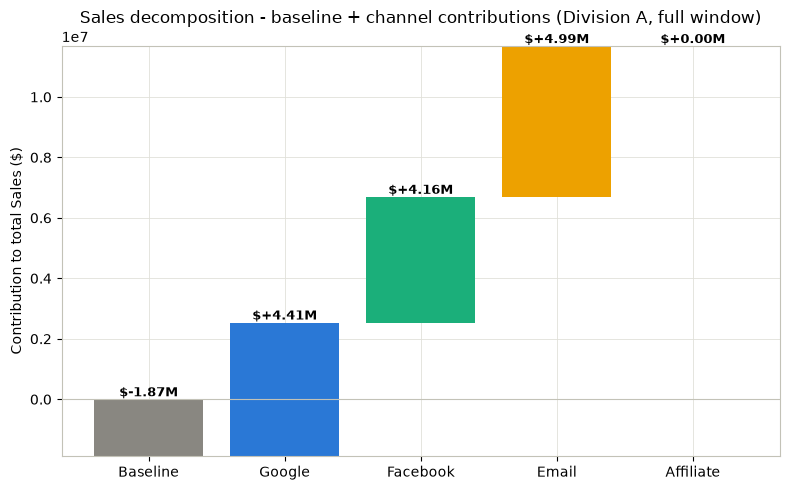

In [21]:
labels = ['Baseline'] + [c.replace('_Impressions', '') for c in CHANNELS]
values = [baseline_constrained.sum()] + [contributions[c].sum() for c in CHANNELS]
colors = [NEUTRAL] + [CHANNEL_COLORS[c] for c in CHANNELS]

fig, ax = plt.subplots(figsize=(8, 5))
cumulative = np.concatenate([[0], np.cumsum(values)[:-1]])
bar_bottoms = np.where(np.array(values) >= 0, cumulative, cumulative + np.array(values))
bar_heights = np.abs(values)

ax.bar(labels, bar_heights, bottom=bar_bottoms, color=colors)
for i, v in enumerate(values):
    ax.annotate(f'${v/1e6:+.2f}M', (i, bar_bottoms[i] + bar_heights[i]), ha='center', va='bottom',
                fontsize=9, fontweight='bold')
ax.axhline(0, color='#c3c2b7', linewidth=0.8)
ax.set_ylabel('Contribution to total Sales ($)')
ax.set_title('Sales decomposition - baseline + channel contributions (Division A, full window)')
plt.tight_layout()
plt.show()


## 11. From contribution to ROI — the CPM-assumption caveat

Section 1 flagged this: **this dataset has impressions, not dollars spent.** Computing a genuine ROI (\$ of Sales per \$ of spend) needs a cost per channel, which doesn't exist here. Rather than silently rebrand "contribution per impression" as "ROI" (which would be misleading) or skip the ROI section entirely (which wouldn't satisfy the actual business question), I'm assigning **illustrative CPM (cost per 1,000 impressions) values per channel**, clearly labeled as assumptions, purely to demonstrate the *mechanics* of converting a contribution decomposition into an ROI readout once real cost data is available:

| Channel | Assumed CPM | Rationale (illustrative) |
|---|---|---|
| Google | \$8.00 | Typical blended search/display CPM order of magnitude |
| Facebook | \$7.00 | Typical paid social CPM order of magnitude |
| Email | \$0.10 | Owned channel — marginal per-send cost is near-zero, not CPM-based in reality |
| Affiliate | \$15.00 | Illustrative stand-in; affiliate is normally commission/CPA-based, not CPM |

**These are not real industry benchmarks to cite elsewhere — they exist only so this section can show the ROI calculation end-to-end.** In production, this table would be replaced with actual platform billing data (Meta Ads Manager spend, Google Ads cost, Apple Search Ads spend), and the ROI ranking below could look completely different — the *transferable* part of this notebook is the pipeline (adstock → saturate → regress → constrain → decompose → divide by real spend), not today's specific dollar figures.


In [22]:
ILLUSTRATIVE_CPM = {
    'Google_Impressions': 8.00,
    'Facebook_Impressions': 7.00,
    'Email_Impressions': 0.10,
    'Affiliate_Impressions': 15.00,
}

roi_rows = []
for c in CHANNELS:
    impressions = division[c].sum()
    spend = impressions / 1000 * ILLUSTRATIVE_CPM[c]
    contribution = contributions[c].sum()
    roi = contribution / spend if spend > 0 else np.nan
    roi_rows.append({
        'channel': c.replace('_Impressions', ''),
        'impressions': impressions,
        'assumed_spend': spend,
        'contribution': contribution,
        'roi': roi,
    })

roi_table = pd.DataFrame(roi_rows).set_index('channel')
roi_table


,impressions,assumed_spend,contribution,roi
channel,,,,
Google,5.540126e+07,443210.072000,4.413433e+06,9.957880
Facebook,1.823524e+07,127646.694000,4.157424e+06,32.569773
Email,4.400593e+07,4400.593082,4.986866e+06,1133.225835
Affiliate,8.912760e+05,13369.140000,0.000000e+00,0.000000


Reading this table honestly rather than just ranking it:

- **Google (~10x) and Facebook (~33x)**: both pass the sanity check of being large-but-plausible for digital channels with meaningfully sized, statistically significant contributions.
- **Email (~1,100x)**: this number is **almost entirely an artifact of the \$0.10 assumed CPM**, not a real claim about email's effectiveness. Email's real-world cost structure isn't CPM-based at all — most ESPs charge a flat platform/subscription fee roughly independent of send volume, so forcing it into a "cost per impression" frame produces a number this sensitive to the assumption. The honest takeaway is qualitative: email is a **high-efficiency, low-marginal-cost channel**, not literally "1,100x return."
- **Affiliate (0x)**: its contribution was constrained to exactly zero in Section 9, so its ROI is zero by construction — the honest read is **"no detectable positive effect at current exposure levels,"** not "affiliate marketing doesn't work." A channel with an order of magnitude fewer impressions than the others (Affiliate averages ~7,900/week vs. Google's ~490,000/week) has much less data to detect an effect from in the first place — this could be a real null effect, or it could be an underpowered one.


## 12. Spend efficiency visualization


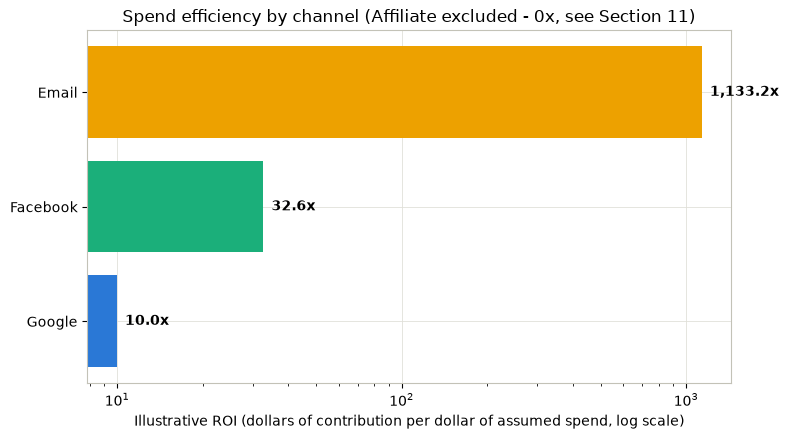

In [23]:
plot_table = roi_table[roi_table['roi'] > 0].sort_values('roi', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4.5))
bar_colors = [CHANNEL_COLORS[f'{ch}_Impressions'] for ch in plot_table.index]
bars = ax.barh(plot_table.index, plot_table['roi'], color=bar_colors)
for bar, roi in zip(bars, plot_table['roi']):
    ax.annotate(f'{roi:,.1f}x', (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                va='center', ha='left', xytext=(6, 0), textcoords='offset points', fontsize=10, fontweight='bold')
ax.set_xscale('log')
ax.set_xlabel('Illustrative ROI (dollars of contribution per dollar of assumed spend, log scale)')
ax.set_title('Spend efficiency by channel (Affiliate excluded - 0x, see Section 11)')
plt.tight_layout()
plt.show()


A log scale is necessary here, not a stylistic choice — Email's assumption-driven ROI is roughly two orders of magnitude above Google and Facebook, and a linear axis would flatten Google and Facebook into indistinguishable slivers next to it. That itself is a visual reminder that Email's number is dominated by the CPM assumption rather than being directly comparable to the other two.


## 13. Where each channel sits on its saturation curve

ROI answers "was the spend so far worth it." It doesn't answer "should the next dollar go here" — that depends on where a channel currently sits on its own saturation curve. A channel with high average ROI that's already deep into diminishing returns has a much lower *marginal* ROI than its average suggests.


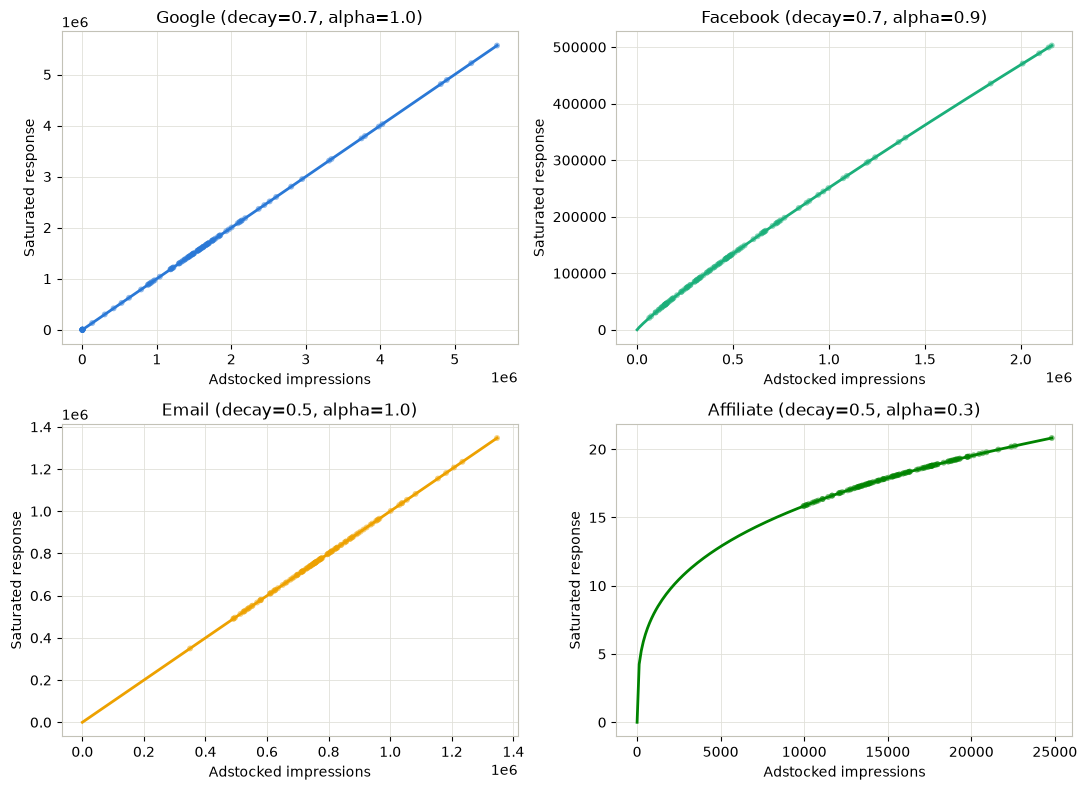

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, c in zip(axes.flat, CHANNELS):
    d, alpha = best_params[c]
    x_raw = division[c].values.astype(float)
    x_adstocked = adstock(x_raw, d)
    x_grid = np.linspace(0, x_adstocked.max(), 200)
    curve = saturate(x_grid, alpha)

    ax.plot(x_grid, curve, color=CHANNEL_COLORS[c], linewidth=2)
    ax.scatter(x_adstocked, saturate(x_adstocked, alpha), color=CHANNEL_COLORS[c], s=18, alpha=0.5,
               edgecolor='none')
    ax.set_title(f"{c.replace('_Impressions', '')} (decay={d}, alpha={alpha})")
    ax.set_xlabel('Adstocked impressions')
    ax.set_ylabel('Saturated response')

plt.tight_layout()
plt.show()


Points are this channel's actual 113 weekly operating levels plotted on its own fitted curve. Google and Facebook were both tuned to alpha near 1 (little curvature — the operating points sit roughly on a straight line), meaning **at these historical spend levels, neither channel shows strong evidence of hitting diminishing returns yet** — a real finding, though bounded by the range of exposure actually observed; this curve says nothing about what happens at 5x today's impressions, which is well outside the data.


## 14. Limitations — named unprompted

- **Impressions, not spend.** The ROI figures in Section 11 rest on assumed CPMs, not observed cost. The channel *ranking* by contribution (Section 10) is data-driven and trustworthy; the dollar ROI figures are a methodology demonstration, not a real finding to act on.
- **Single division, not a panel model.** 25 other valid divisions in this dataset were not used. A production MMM would pool across markets with a hierarchical model rather than pick one and ignore the rest — I did the latter here for a fully inspectable single time series.
- **Per-channel univariate parameter tuning, not joint optimization.** Decay and saturation alpha were each chosen to maximize that channel's own trend-controlled correlation with Sales, independently of the other channels. Production tools (Robyn, LightweightMMM) tune all channels' hyperparameters jointly inside the full model, typically via Bayesian or evolutionary search — this is a materially more rigorous (and more compute-intensive) approach that a from-scratch interview notebook is simplifying away from.
- **Point estimates for adstock/saturation, not propagated uncertainty.** Decay and alpha were tuned, then treated as fixed constants in the OLS/bounded-regression stage — so the reported coefficient confidence intervals understate the true uncertainty, which also includes "how sure are we about the tuned decay and alpha themselves." A Bayesian MMM (e.g., PyMC-Marketing, Google's Meridian) treats these as model parameters with priors and propagates that uncertainty end-to-end instead.
- **Negative implied baseline (Section 9)** — a known artifact of the linear-additive specification extrapolating the fitted trend to a zero-media counterfactual outside the data's support. A log-linear specification is the standard production fix; not implemented here to keep the notebook's core methodology (adstock/saturation/ROI) legible.
- **No out-of-sample validation.** The model was fit and evaluated on the same 113 weeks. A production MMM would hold out the most recent N weeks, check forecast accuracy, and only then trust the derived ROI enough to shift budget on it.
- **Linear trend + month dummies is a coarse seasonality control.** No holidays, promotions, pricing changes, or competitor activity are modeled, all of which a real MMM typically includes as additional controls when available.


## 15. Summary — what I'd say in an interview

**What this notebook does**: builds a full Marketing Mix Model pipeline — geometric adstock for carryover, a power-law saturation transform for diminishing returns, per-channel hyperparameter tuning via trend-controlled partial correlation, an OLS regression with trend/seasonality controls, a non-negativity-constrained refit to fix a collinearity-driven sanity-check failure, and a channel-level ROI/spend-efficiency readout — on a structurally equivalent public dataset, because real mobile game UA channel spend data is commercially sensitive and doesn't exist publicly. Every step of this pipeline generalizes directly to Meta/Google UAC/Apple Search Ads spend data with installs or revenue as the outcome.

**Why this matters for the business question**: MMM is attribution-agnostic by construction — it works off aggregate weekly spend and outcomes, so SKAdNetwork thresholds, ATT opt-out rates, and MMP-vs-network discrepancies simply don't enter the model. That's precisely why MMM has become the standard complement to (and sometimes replacement for) user-level attribution for UA budget decisions industry-wide.

**What I'd flag as limitations, unprompted**:
- The naive (unconstrained) regression produced an economically implausible -620x "ROI" for one channel — I caught this with a sanity check rather than reporting it, diagnosed the cause (collinearity allowing implausible offsetting credit in a good-fitting model), and fixed it with a non-negativity constraint standard in production MMM tools.
- ROI figures depend on assumed CPMs because this dataset has impressions, not spend — the channel contribution ranking is trustworthy; the dollar ROI figures are a methodology demonstration.
- Parameter tuning (adstock decay, saturation alpha) is a univariate pre-tuning heuristic, not the joint Bayesian/evolutionary optimization production tools use — and the resulting point-estimate parameters aren't propagated through as uncertainty in the final coefficient CIs.
- Single division modeled in isolation; no pooling across the other 25 valid markets in this dataset; no out-of-sample validation; coarse seasonality controls; a linear-additive specification that implies an economically meaningless negative baseline under extrapolation.
